### Импорт библиотек и загрузка изображения

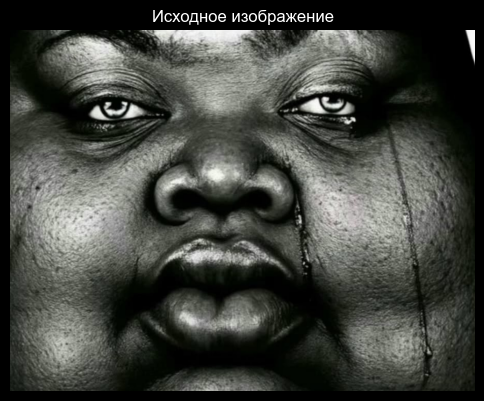

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(image, title="", cmap=None):
    plt.figure(figsize=(6, 6))
    plt.title(title)

    if cmap is None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image, cmap=cmap)
    plt.axis('off')
    plt.show()

img = cv2.imread('image.jpg')
img_gray = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

show_image(img, "Исходное изображение")

### Задание 1.  Построить гистограмму изображения и определить минимум, максимум и медиану яркости.

Минимальная яркость: 0
Максимальная яркость: 255
Медиана яркости: 69.0


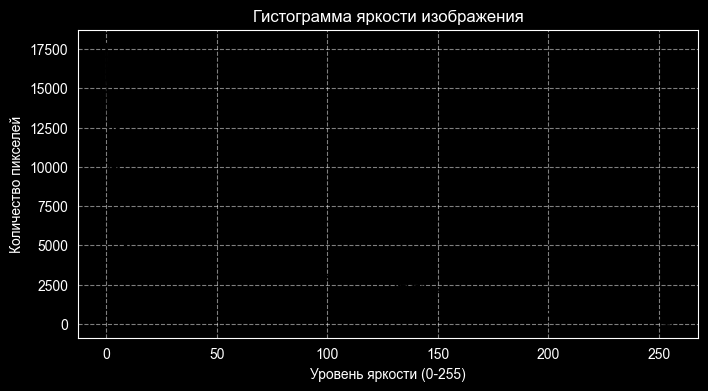

In [13]:
min_val = np.min(img_gray)
max_val = np.max(img_gray)
median_val = np.median(img_gray)

print(f"Минимальная яркость: {min_val}")
print(f"Максимальная яркость: {max_val}")
print(f"Медиана яркости: {median_val}")

hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist, color='black')
plt.title('Гистограмма яркости изображения')
plt.xlabel('Уровень яркости (0-255)')
plt.ylabel('Количество пикселей')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Задание 2. Построить профили изображения после применения фильтра «Собель» по X и Y.

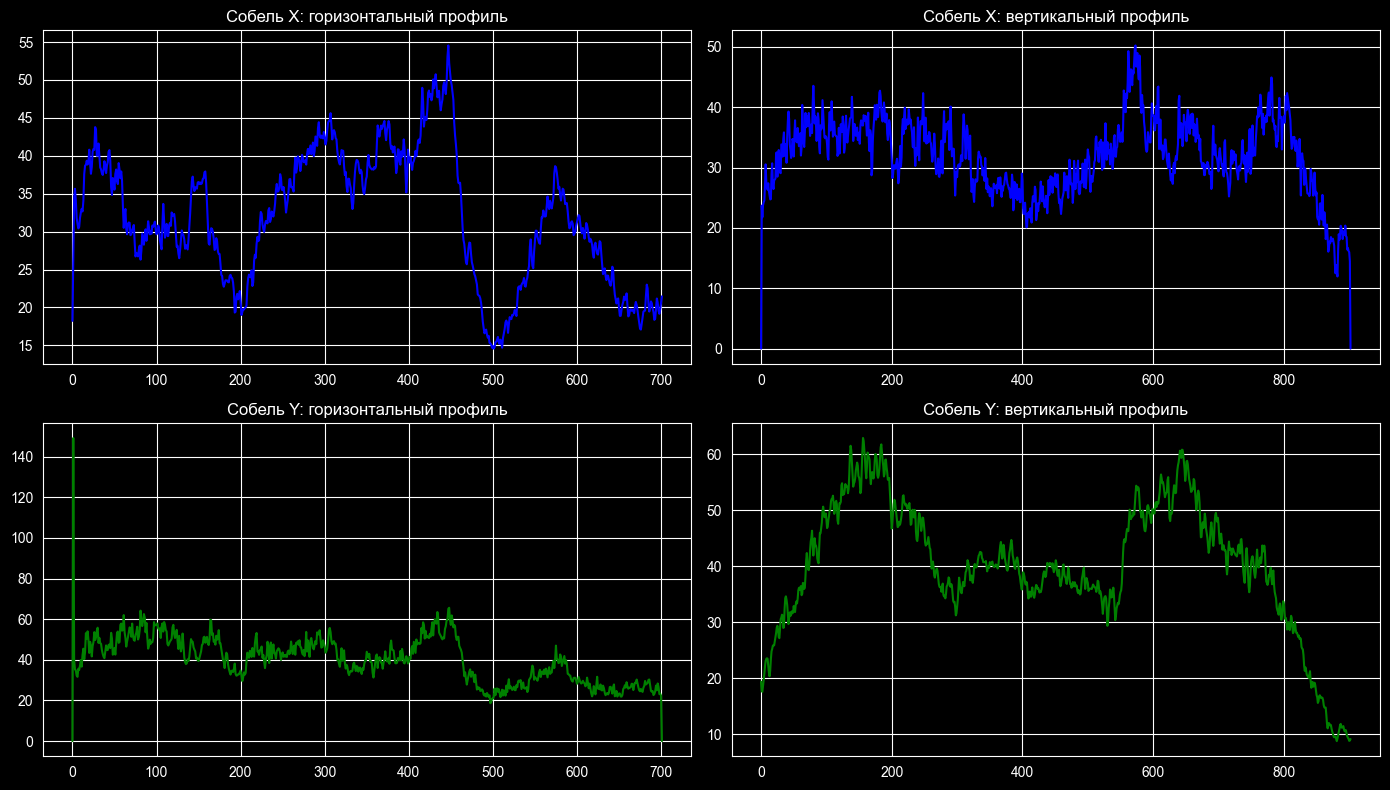

In [14]:
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

prof_hx = np.mean(sobel_x, axis=1)
prof_vx = np.mean(sobel_x, axis=0)

prof_hy = np.mean(sobel_y, axis=1)
prof_vy = np.mean(sobel_y, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(prof_hx, color='blue')
axes[0, 0].set_title('Собель X: горизонтальный профиль')

axes[0, 1].plot(prof_vx, color='blue')
axes[0, 1].set_title('Собель X: вертикальный профиль')

axes[1, 0].plot(prof_hy, color='green')
axes[1, 0].set_title('Собель Y: горизонтальный профиль')

axes[1, 1].plot(prof_vy, color='green')
axes[1, 1].set_title('Собель Y: вертикальный профиль')

plt.tight_layout()
plt.show()

### Задание 3. Построить горизонтальную и вертикальную проекции цветного изображения (суммируя по каналам).

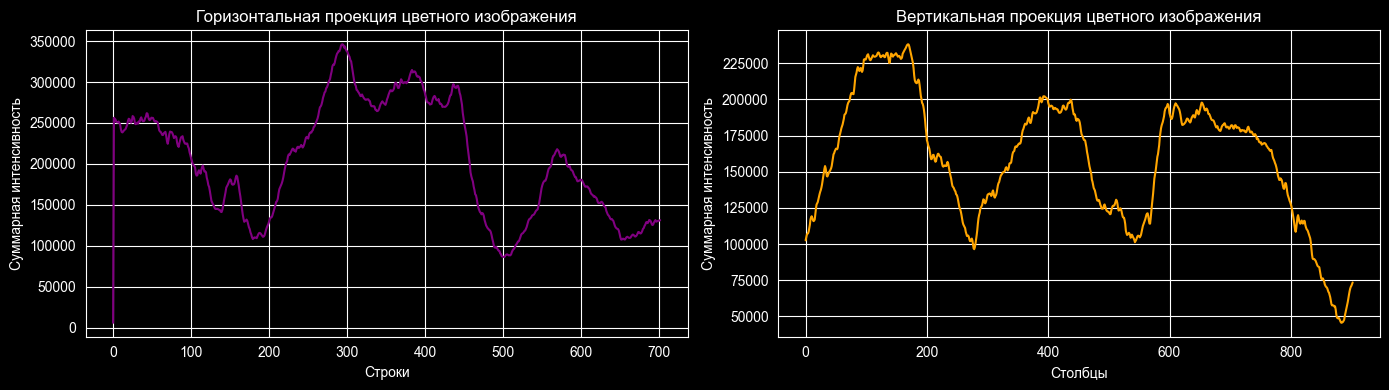

In [15]:
img_sum_channels = np.sum(img, axis=2)

proj_h_color = np.sum(img_sum_channels, axis=1)

proj_v_color = np.sum(img_sum_channels, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(proj_h_color, color='purple')
axes[0].set_title('Горизонтальная проекция цветного изображения')
axes[0].set_xlabel('Строки')
axes[0].set_ylabel('Суммарная интенсивность')

axes[1].plot(proj_v_color, color='orange')
axes[1].set_title('Вертикальная проекция цветного изображения')
axes[1].set_xlabel('Столбцы')
axes[1].set_ylabel('Суммарная интенсивность')

plt.tight_layout()
plt.show()

### Задание 4. Найти строки с пикселями выше порога в горизонтальной проекции бинарного изображения.

Порог для горизонтальной проекции: 49228.8
Количество строк выше порога: 325
Первые 10 найденных строк: [ 1  2  3  4  5  6  7  8  9 10]


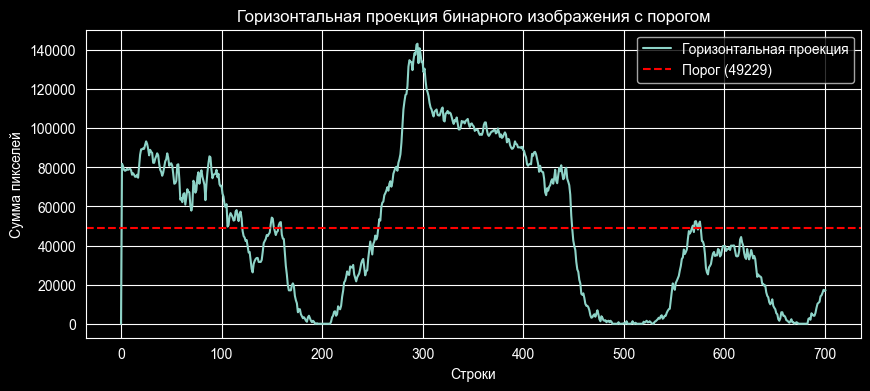

In [16]:
_, img_bin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

proj_bin_h = np.sum(img_bin, axis=1)

threshold_row = np.mean(proj_bin_h)

rows_above_thresh = np.where(proj_bin_h > threshold_row)[0]

print(f"Порог для горизонтальной проекции: {threshold_row:.1f}")
print(f"Количество строк выше порога: {len(rows_above_thresh)}")
print("Первые 10 найденных строк:", rows_above_thresh[:10])

plt.figure(figsize=(10, 4))
plt.plot(proj_bin_h, label='Горизонтальная проекция')
plt.axhline(y=threshold_row, color='r', linestyle='--', label=f'Порог ({threshold_row:.0f})')
plt.title('Горизонтальная проекция бинарного изображения с порогом')
plt.xlabel('Строки')
plt.ylabel('Сумма пикселей')
plt.legend()
plt.show()

### Задание 5. Найти столбцы с пикселями выше порога в вертикальной проекции бинарного изображения.

Порог для вертикальной проекции: 38270.9
Количество столбцов выше порога: 474
Первые 10 найденных столбцов: [57 58 59 60 61 62 63 64 65 66]


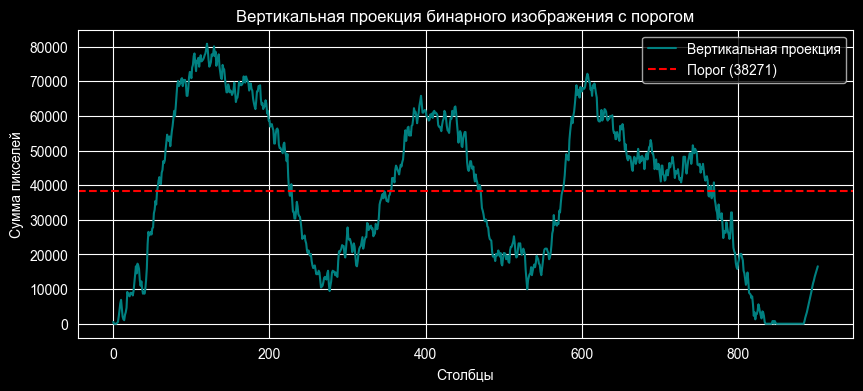

In [17]:
proj_bin_v = np.sum(img_bin, axis=0)

threshold_col = np.mean(proj_bin_v)

cols_above_thresh = np.where(proj_bin_v > threshold_col)[0]

print(f"Порог для вертикальной проекции: {threshold_col:.1f}")
print(f"Количество столбцов выше порога: {len(cols_above_thresh)}")
print("Первые 10 найденных столбцов:", cols_above_thresh[:10])

plt.figure(figsize=(10, 4))
plt.plot(proj_bin_v, color='teal', label='Вертикальная проекция')
plt.axhline(y=threshold_col, color='r', linestyle='--', label=f'Порог ({threshold_col:.0f})')
plt.title('Вертикальная проекция бинарного изображения с порогом')
plt.xlabel('Столбцы')
plt.ylabel('Сумма пикселей')
plt.legend()
plt.show()